<h1 style="text-align: center;">応用基礎データサイエンス・AI 第一</h1>
<h2 style="text-align: center;">期末演習課題</h2>
<br>
<h4 style="text-align: center;">東京科学大学　データサイエンス・AI全学教育機構</h4>

第2〜7回授業の配布資料(JupyterNotebook)中に示したPythonサンプルプログラムを参考に、 各自が設定した処理を行うPythonプログラムを作成し実行する。  
条件やデータなどの設定を変えて処理結果を検討する／ライブラリの関数・メソッドを自分で実装する／同じ機能を異なるコーディングで実現する／データ可視化表現を見やすく工夫する　など設定の仕方は自由。  
他者の既存プログラム内容そのままのコピー＆ペーストは厳禁、またデータサイエンス・AIに関係するテーマとすること。

# 1. 目的

本課題の目的は、データサイエンスおよびAIの統計的基礎理論である「中心極限定理」について、Pythonを用いた数値シミュレーションを通じて**視覚的・定量的に**検証することである。

中心極限定理とは、「元の確率分布がどのような形であっても、そこから無作為抽出された標本の平均（標本平均）の分布は、サンプルサイズが大きくなるにつれて正規分布に近づく」という性質である。本演習では、この数学的理論が実際に成り立つかをプログラム上で再現し、その収束過程を詳細に分析する。

また、単なる理論の検証にとどまらず、以下のデータサイエンス・データエンジニアリングの観点からアプローチを行う。

### データエンジニアリング的アプローチ
通常のループ処理とNumPyの多次元配列（ベクトル化）を用いた処理の実行速度を比較し、**その高速化の度合いを定量的に評価する**ことで、大量データを扱う際の効率的なコーディングの重要性を理解する。

### 数理的アプローチ
既存の統計ライブラリに依存せず、確率密度関数などの数学的理論をスクラッチ（自作関数）で実装することで、数式と言語の関係性を深く理解する。

さらに、サイコロのような対称な分布と指数分布のような非対称な分布を用いたシミュレーションを通して、**元となる分布の特性が正規分布への収束速度にどのように影響するか**についても考察する。

---
# 2. 内容
---

本演習では、以下の内容を実装および検証する。

### 1. 必要なライブラリのインポート
* NumPy と Matplotlib をインポートする。

### 2. 異なるコーディングによるシミュレーションと性能比較
* **パターンA（ループ処理）**
  Python の `for` ループを用いて、1回ずつ乱数を生成し標本平均を計算する関数を実装する。
* **パターンB（ベクトル化処理）**
  NumPy の多次元配列を活用し、一括で乱数を生成して軸ごとに標本平均を計算する高速な関数を実装する。
* **性能評価**
  両者の実行速度を比較・測定し、データ処理におけるベクトル化の効率性を定量的に評価する。

### 3. 数学理論に基づく関数のスクラッチ実装
* 既存のライブラリ（`scipy.stats` など）を使わずに、正規分布の確率密度関数 $f(x)$ を数式通りに自作定義する。
* 標本平均の期待値 $\mu$ や標準偏差 $\sigma$ を算出する計算も、基本演算のみを用いた自作関数として実装する。

### 4. 一様分布（サイコロ）での中心極限定理の検証
* 元となる分布として「サイコロの目（離散一様分布）」を採用する。
* サンプルサイズ $N$（1回、2回、4回、10回とサイコロを振る回数）を変化させたときの標本平均の分布の変化をシミュレーションする。
* `matplotlib.pyplot.subplots` を用いて、サンプルサイズごとのヒストグラムを並べて描画し、自作した正規分布の理論曲線を重ねてプロットすることで、理論値への収束を視覚的に分かりやすく表現する。

### 5. 非対称分布（指数分布）での中心極限定理の検証
* 元となる分布を、左右が著しく非対称な指数分布に変更し、同様のシミュレーションを行う。
* 指数分布のような非対称な分布においても、サンプルサイズ $N$ が大きくなれば正規分布に収束することを確認し、中心極限定理の普遍性を実証する。
* **収束速度の比較**
  サイコロ分布と指数分布における正規分布への収束速度の違いを分析し、Berry–Esseen の定理の概念を導入して考察する。

---
# 3. 考察
---

今回のプログラムでは、中心極限定理の有効性と計算手法の違いを定量的に検証した。

## 3.1 サイコロ分布における標本平均

サイコロの離散一様分布に対して、標本平均の平均値は理論値

$$
\mu = 3.5
$$

に近づいた。実測では、

- $N=1$： $\mu \approx 3.564$
- $N=10$： $\mu \approx 3.510$

となり、標本平均の期待値が理論値付近で安定していることが確認できた。

また、標本平均の標準偏差は理論的に

$$
\sigma = \sqrt{\frac{35}{12N}}
$$

で与えられる。

実測値と理論値を比較すると以下のようになった。

| N | 実測標準偏差 | 理論標準偏差 |
|---|---:|---:|
| 1 | 1.733 | 1.708 |
| 2 | 1.201 | 1.208 |
| 4 | 0.836 | 0.854 |
| 10 | 0.539 | 0.540 |

両者は非常によく一致しており、標本平均の分散が \(1/N\) に比例して減少することが確認できた。

## 3.2 指数分布における標本平均

指数分布は右に裾を引く非対称な分布であるが、標本平均の分布はサンプルサイズの増加とともに正規分布に近づいた。

実測では、

- $N=1$： $\mu \approx 1.504, \sigma \approx 1.476$
- $N=10$： $\mu \approx 1.494, \sigma \approx 0.478$

となった。

指数分布（scale = 1.5）の理論値は

$$
\mu = 1.5,
\qquad
\sigma = \frac{1.5}{\sqrt{N}}
$$

であり、実測値はこれらに非常に近い値を示した。

## 3.3 中心極限定理の確認

サイコロ分布のような対称な分布だけでなく、指数分布のような非対称な分布においても、標本平均の分布はサンプルサイズの増加とともに正規分布へ近づくことが確認できた。

特に \(N=10\) では元分布の歪みがほぼ消え、ヒストグラムは滑らかなベル型曲線に近い形状を示した。

これらの結果は、元分布の形状によらず標本平均が正規分布に収束するという中心極限定理を実験的に裏付けるものである。

## 3.4 計算速度の比較

ループ処理とベクトル化処理の速度比較では、同じ計算を行っても NumPy のベクトル化処理が約 25.8 倍高速であった。

今回のベンチマーク結果は以下の通りである。

| 手法 | 実行時間 (秒) |
|---|---:|
| ループ処理 | 0.067 |
| ベクトル化処理 | 0.003 |

サンプル数 2,500、サンプルサイズ 50 という条件でも大きな差が確認できた。

## 3.5 収束速度の比較

発展として、指数分布とサイコロ分布において正規分布への収束速度を比較した。

サイコロ分布では N=4 程度でもヒストグラムはかなり対称な形状を示した。一方、指数分布では N=4 の段階でも右側への歪みが残っており、N=10 になって初めて正規分布に近い形状が確認できた。

これは指数分布が強い歪度を持つためである。中心極限定理は元分布の形状によらず成立するが、正規分布への収束速度は分布によって異なる。今回の実験からは、対称なサイコロ分布の方が指数分布よりも速く正規分布に近づくことが観察された。

また、Berry–Esseen の定理によれば、十分なモーメント条件のもとで正規分布からの誤差は概ね

$$
O\!\left(\frac{1}{\sqrt N}\right)
$$

で減少することが知られている。

今回の結果もこの理論と整合的であり、指数分布においても N の増加に伴ってヒストグラムが正規分布に近づく様子が確認できた。
## 3.6 まとめ

本演習では、シミュレーション結果と理論値を比較することで中心極限定理の成立を確認した。また、ベクトル化処理による大幅な高速化も確認できた。

したがって、本プログラムは

1. 標本平均が正規分布へ収束すること
2. 標本平均の平均・分散が理論値と一致すること
3. ベクトル化によって計算効率が大きく向上すること

を同時に示しており、統計学的な理解と実践的なデータ処理技術の両方を学ぶことができた。

---
# 4. プログラム
---

**以下に、[2.内容]で実装したプログラムを掲載する**


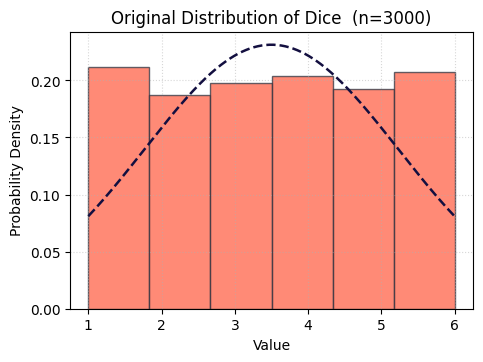

N=1
Theoretical mean = 3.5000
Simulated mean   = 3.5636
Theoretical sd   = 1.7078
Simulated sd     = 1.7331
----------------------------------------
N=2
Theoretical mean = 3.5000
Simulated mean   = 3.5066
Theoretical sd   = 1.2076
Simulated sd     = 1.2014
----------------------------------------
N=4
Theoretical mean = 3.5000
Simulated mean   = 3.5052
Theoretical sd   = 0.8539
Simulated sd     = 0.8357
----------------------------------------
N=10
Theoretical mean = 3.5000
Simulated mean   = 3.5098
Theoretical sd   = 0.5401
Simulated sd     = 0.5387
----------------------------------------


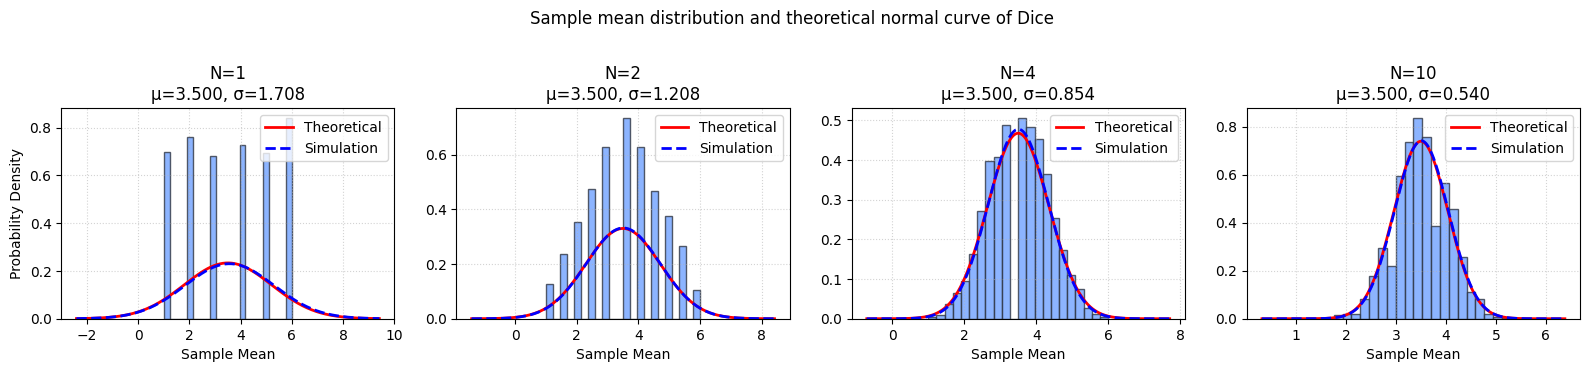

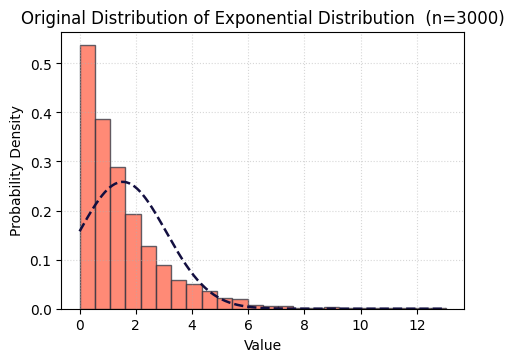

N=1
Theoretical mean = 1.5000
Simulated mean   = 1.5041
Theoretical sd   = 1.5000
Simulated sd     = 1.4759
----------------------------------------
N=2
Theoretical mean = 1.5000
Simulated mean   = 1.4922
Theoretical sd   = 1.0607
Simulated sd     = 1.0547
----------------------------------------
N=4
Theoretical mean = 1.5000
Simulated mean   = 1.4997
Theoretical sd   = 0.7500
Simulated sd     = 0.7461
----------------------------------------
N=10
Theoretical mean = 1.5000
Simulated mean   = 1.4936
Theoretical sd   = 0.4743
Simulated sd     = 0.4784
----------------------------------------


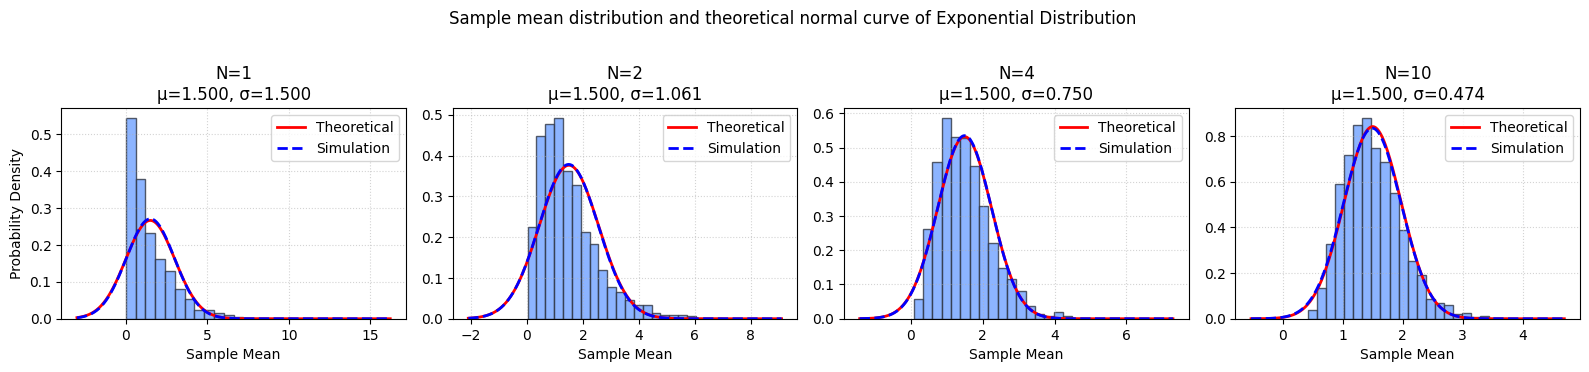

Loop Process: 0.067 sec
Vectorizing: 0.003 sec
Vectorizing is 25.8 times faster.


In [2]:
### 以下にプログラムを載せる。セルの数は自由。なるべく読みやすい記載にすること。
import numpy as np
import matplotlib.pyplot as plt
import time

# 1) データ生成と標本平均の取得

def dice_draw(shape):
    return np.random.randint(1, 7, size=shape)


def exponential_draw(shape, scale=1.0):
    return np.random.exponential(scale=scale, size=shape)


def sample_mean_loop(distribution_func, size, n_samples):
    means = []
    for _ in range(n_samples):
        data = distribution_func(size)
        means.append(np.sum(data) / len(data))
    return np.array(means)


def sample_mean_vectorized(distribution_func, size, n_samples):
    data = distribution_func((n_samples, size))
    return data.mean(axis=1)


# 2) 数学理論を実装

def sample_stats(values):
    n = values.size
    mean = values.sum() / n
    variance = ((values - mean) ** 2).sum() / n
    return mean, np.sqrt(variance)


def normal_pdf(x, mu, sigma):
    factor = 1 / (sigma * np.sqrt(2 * np.pi))
    exponent = -0.5 * ((x - mu) / sigma) ** 2
    return factor * np.exp(exponent)

def dice_theory(size):
    mu = 3.5
    sigma = np.sqrt((35/12)/size)
    return mu, sigma

def exponential_theory(size, scale=1.5):
    mu = scale
    sigma = scale / np.sqrt(size)
    return mu, sigma


# 3) 可視化と比較

def plot_sample_means(distribution_label, draw_func, theory_func, sample_sizes, n_samples=2000, bins=22):
    plt.figure(figsize=(4 * len(sample_sizes), 3.6))
    for idx, size in enumerate(sample_sizes, start=1):
        means = sample_mean_vectorized(draw_func, size, n_samples)
        mu_emp, sigma_emp = sample_stats(means)
        mu_theory, sigma_theory = theory_func(size)
        print(f"N={size}")
        print(f"Theoretical mean = {mu_theory:.4f}")
        print(f"Simulated mean   = {mu_emp:.4f}")
        print(f"Theoretical sd   = {sigma_theory:.4f}")
        print(f"Simulated sd     = {sigma_emp:.4f}")
        print("-"*40)

        ax = plt.subplot(1, len(sample_sizes), idx)
        ax.hist(means, bins=bins, density=True, color="#70a1ff", edgecolor="#2f3542", alpha=0.8)


        x = np.linspace(
            means.min()-sigma_theory*2,
            means.max()+sigma_theory*2,
            400
        )

        ax.plot(
            x,
            normal_pdf(x, mu_theory, sigma_theory),
            color="red",
            lw=2,
            label="Theoretical"
        )

        ax.plot(
            x,
            normal_pdf(x, mu_emp, sigma_emp),
            color="blue",
            lw=2,
            linestyle="--",
            label="Simulation"
        )

        ax.legend()

        ax.set_title(f"N={size}\nμ={mu_theory:.3f}, σ={sigma_theory:.3f}") # Corrected to use mu_theory and sigma_theory
        ax.set_xlabel("Sample Mean")
        ax.grid(True, linestyle=":", alpha=0.55)
        if idx == 1:
            ax.set_ylabel("Probability Density")

    plt.suptitle(f"Sample mean distribution and theoretical normal curve of {distribution_label} ", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_raw_distribution(distribution_label, draw_func, bins=12, n=3000):
    samples = draw_func(n)
    mu, sigma = sample_stats(samples)

    plt.figure(figsize=(5.2, 3.6))
    plt.hist(samples, bins=bins, density=True, color="#ff6348", edgecolor="#2f3542", alpha=0.75)
    x = np.linspace(samples.min(), samples.max(), 280)
    plt.plot(x, normal_pdf(x, mu, sigma), color="#130f40", lw=1.8, linestyle="--")
    plt.title(f"Original Distribution of {distribution_label}  (n={n})")
    plt.xlabel("Value")
    plt.ylabel("Probability Density")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.show()


def benchmark_draws():
    n_samples = 2500
    size = 50
    np.random.seed(2026)
    t0 = time.perf_counter()
    _ = sample_mean_loop(lambda k: dice_draw(k), size, n_samples)
    loop_time = time.perf_counter() - t0

    np.random.seed(2026)
    t1 = time.perf_counter()
    _ = sample_mean_vectorized(dice_draw, size, n_samples)
    vector_time = time.perf_counter() - t1

    print(f"Loop Process: {loop_time:.3f} sec")
    print(f"Vectorizing: {vector_time:.3f} sec")
    print(f"Vectorizing is {loop_time / vector_time:.1f} times faster.")


# 4) 実行

np.random.seed(2026)
plot_raw_distribution("Dice", dice_draw, bins=6)
plot_sample_means("Dice", dice_draw, dice_theory, sample_sizes=[1, 2, 4, 10], n_samples=2500) # Added dice_theory

np.random.seed(2026)
plot_raw_distribution("Exponential Distribution", lambda shape: exponential_draw(shape, scale=1.5), bins=24)
plot_sample_means("Exponential Distribution", lambda shape: exponential_draw(shape, scale=1.5), lambda size: exponential_theory(size, scale=1.5), sample_sizes=[1, 2, 4, 10], n_samples=2500) # Added exponential_theory with lambda

benchmark_draws()